In [1]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

import lightgbm as lgb
import xgboost as xgb


In [2]:
#Load train and test datasets
train = pd.read_csv("Titanic_train.csv")
test = pd.read_csv("Titanic_test.csv")

## Exploratory Data Analysis (EDA):

In [3]:
#Display train head
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
#Display test head
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
# Dataset shape
print("Dataset Shape:", train.shape)
print("Dataset Shape:", test.shape)

Dataset Shape: (891, 12)
Dataset Shape: (418, 11)


In [6]:
# Display data types and null info
train.info()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass  

In [7]:
test.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,418.0,1100.500000,120.810458,892.00,996.2500,1100.5000,1204.75,1309.0000
Pclass,418.0,2.265550,0.841838,1.00,1.0000,3.0000,3.00,3.0000
Age,332.0,30.272590,14.181209,0.17,21.0000,27.0000,39.00,76.0000
SibSp,418.0,0.447368,0.896760,0.00,0.0000,0.0000,1.00,8.0000
Parch,418.0,0.392344,0.981429,0.00,0.0000,0.0000,0.00,9.0000
Fare,417.0,35.627188,55.907576,0.00,7.8958,14.4542,31.50,512.3292


In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [9]:
print("Missing values in Train:")
print(train.isnull().sum())

print("\nMissing values in Test:")
print(test.isnull().sum())

Missing values in Train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values in Test:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


The dataset contains missing values primarily in Age, Cabin, Embarked (train), and Fare (test), which will be handled appropriately during preprocessing.

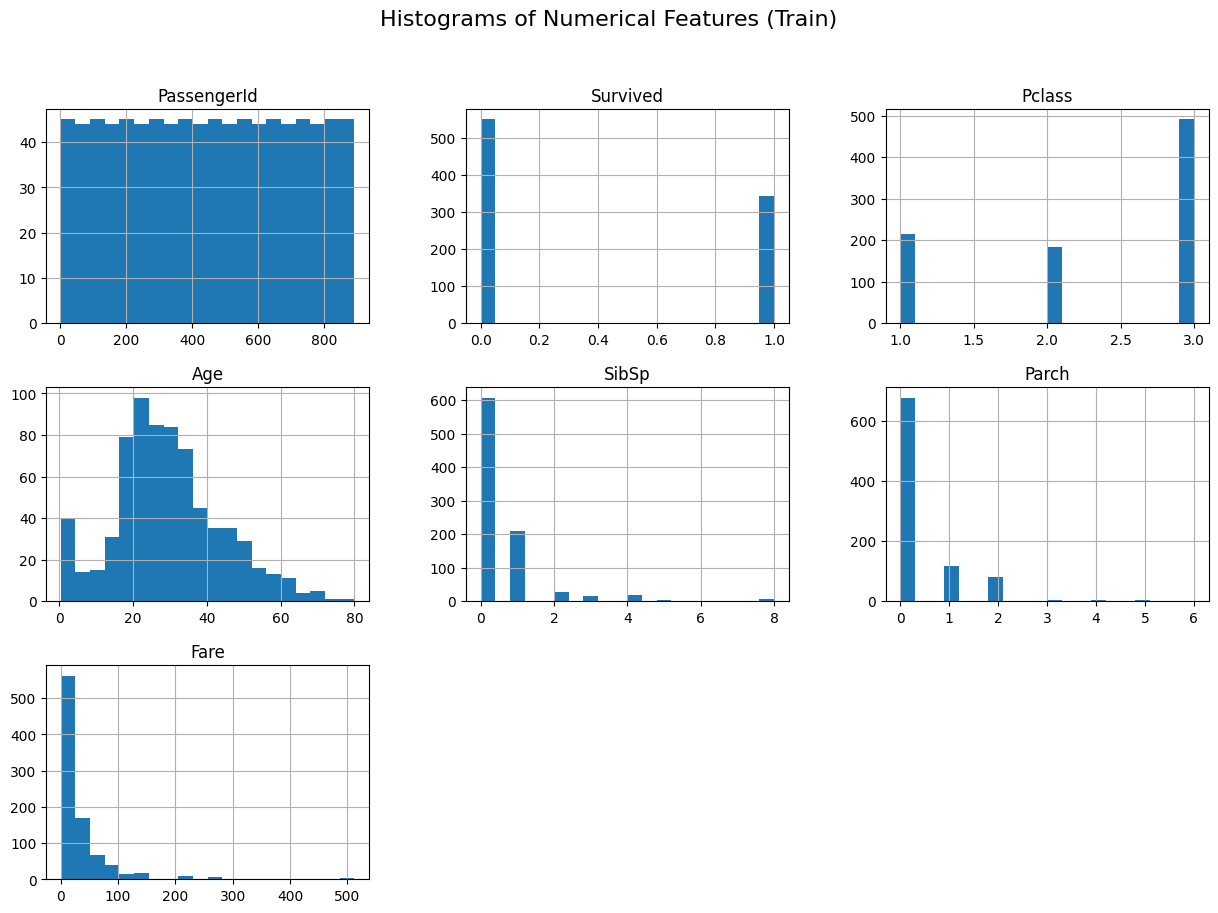

In [10]:
# Data Distribution - Train
train.hist(bins=20, figsize=(15,10))
plt.suptitle("Histograms of Numerical Features (Train)", fontsize=16)
plt.show()

The distributions indicate that Fare is highly positively skewed, while Age is approximately normally distributed with most passengers between 20–40 years

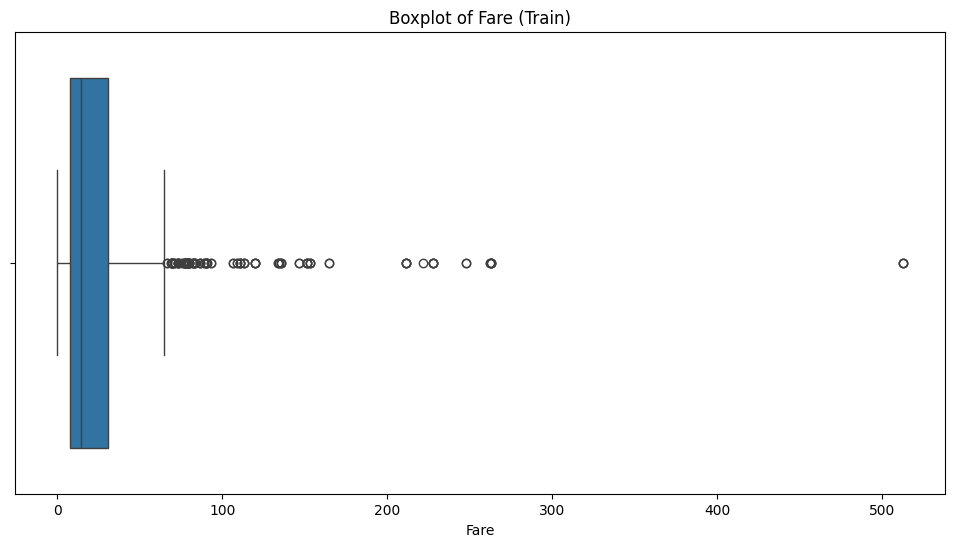

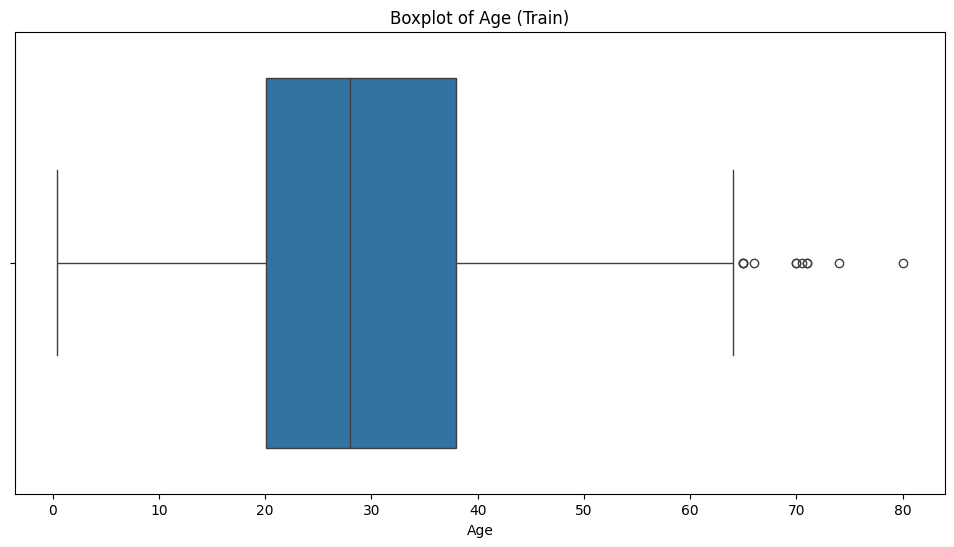

In [11]:
# Boxplots (Train)
plt.figure(figsize=(12,6))
sns.boxplot(x=train['Fare'])
plt.title("Boxplot of Fare (Train)")
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x=train['Age'])
plt.title("Boxplot of Age (Train)")
plt.show()

- Fare has many extreme outliers (some very high ticket prices).
- Age has a few higher-age outliers but overall a reasonable spread.

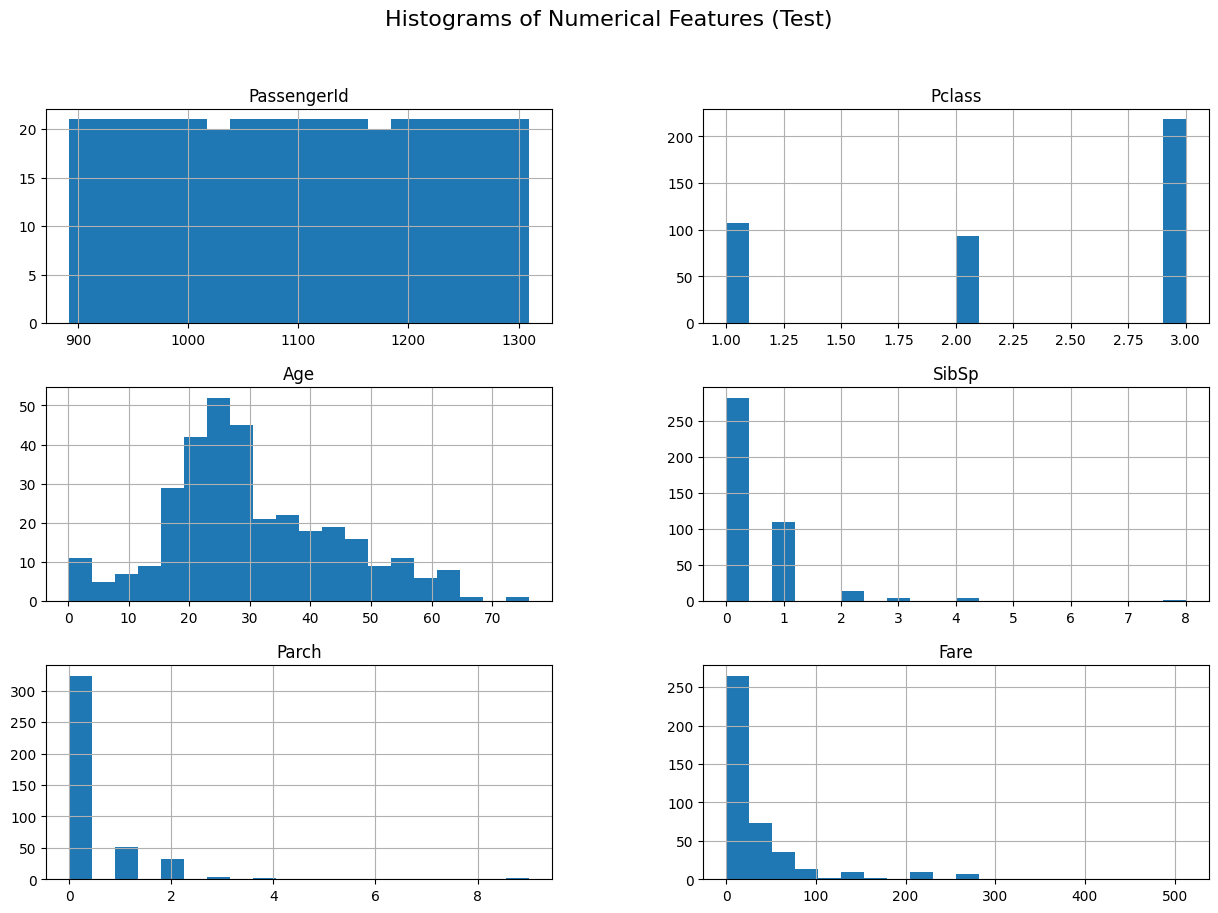

In [12]:
# Data Distribution - Test
#Histogram
test.hist(bins=20, figsize=(15,10))
plt.suptitle("Histograms of Numerical Features (Test)", fontsize=16)
plt.show()

The test data looks similar to the train data. Most passengers are in 3rd class, most ages are between 20–40, and fare is mostly low with a few very high values.”

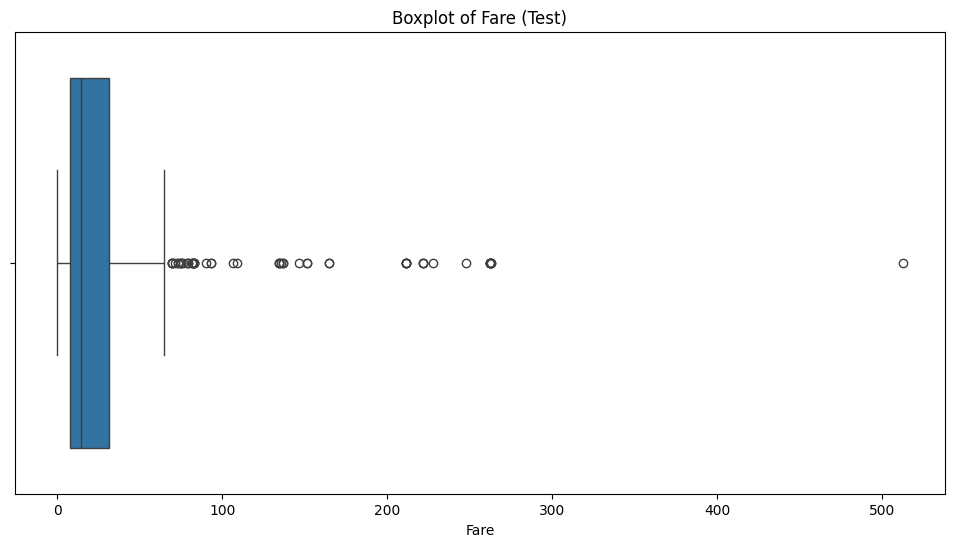

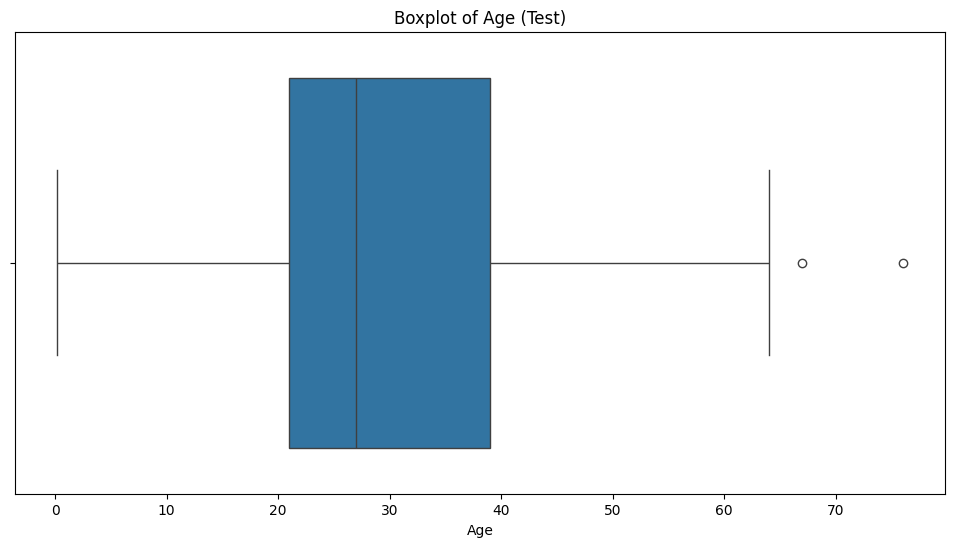

In [13]:
# Boxplots (Test)
plt.figure(figsize=(12,6))
sns.boxplot(x=test['Fare'])
plt.title("Boxplot of Fare (Test)")
plt.show()

if "Age" in test.columns:
    plt.figure(figsize=(12,6))
    sns.boxplot(x=test['Age'])
    plt.title("Boxplot of Age (Test)")
    plt.show()

- In the test data, Fare has many high outliers, showing that some passengers paid very high ticket prices.
- Age is mostly spread between young and middle-aged people, with only a few extreme values.

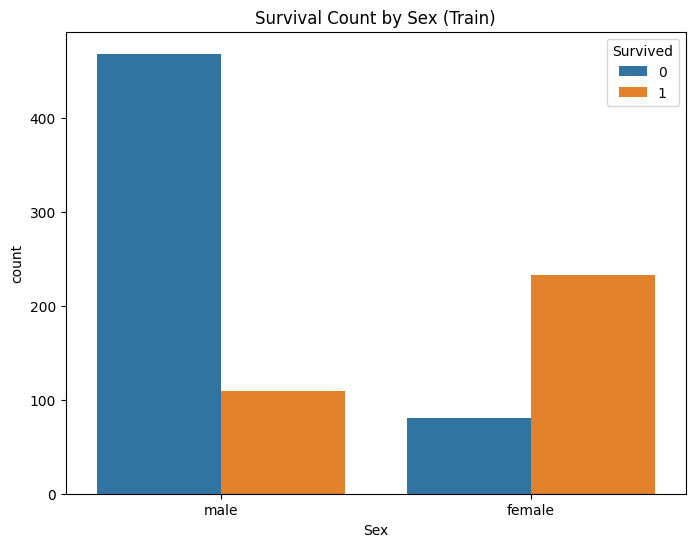

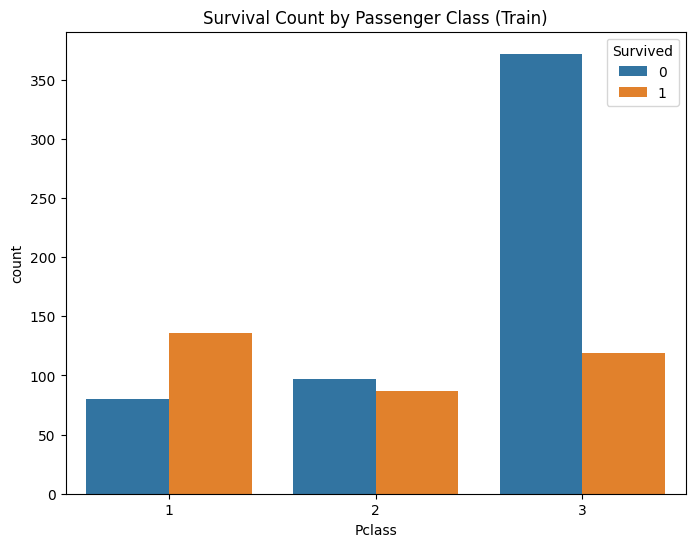

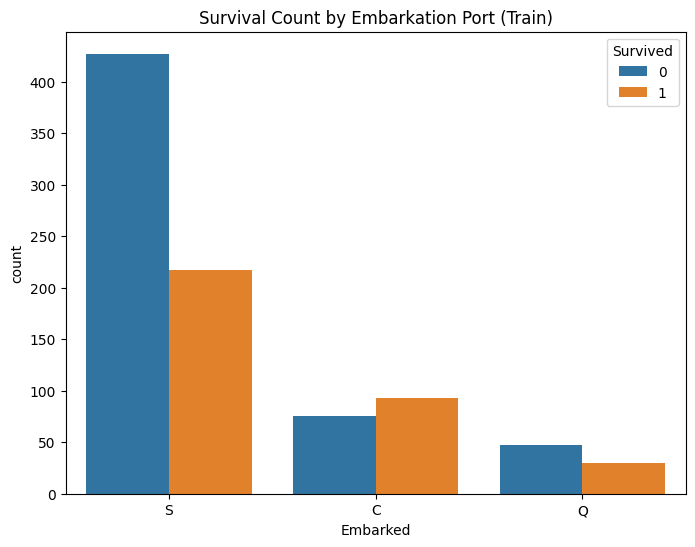

In [14]:
# Relationships with Survival (only in Train, since Test lacks labels)
plt.figure(figsize=(8,6))
sns.countplot(x="Sex", hue="Survived", data=train)
plt.title("Survival Count by Sex (Train)")
plt.show()

plt.figure(figsize=(8,6))
sns.countplot(x="Pclass", hue="Survived", data=train)
plt.title("Survival Count by Passenger Class (Train)")
plt.show()

plt.figure(figsize=(8,6))
sns.countplot(x="Embarked", hue="Survived", data=train)
plt.title("Survival Count by Embarkation Port (Train)")
plt.show()

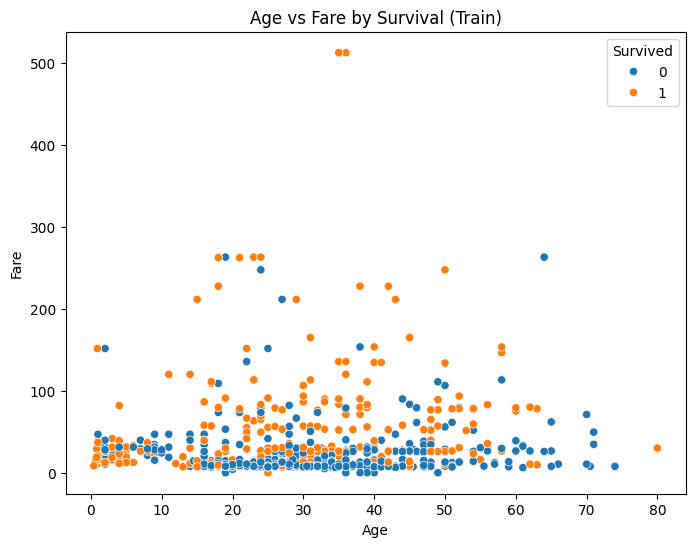

In [15]:
# Scatter plots
plt.figure(figsize=(8,6))
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=train)
plt.title("Age vs Fare by Survival (Train)")
plt.show()

- Passengers who paid higher fares had better survival chances.
- Age does not show a very clear difference between survived and not survived.

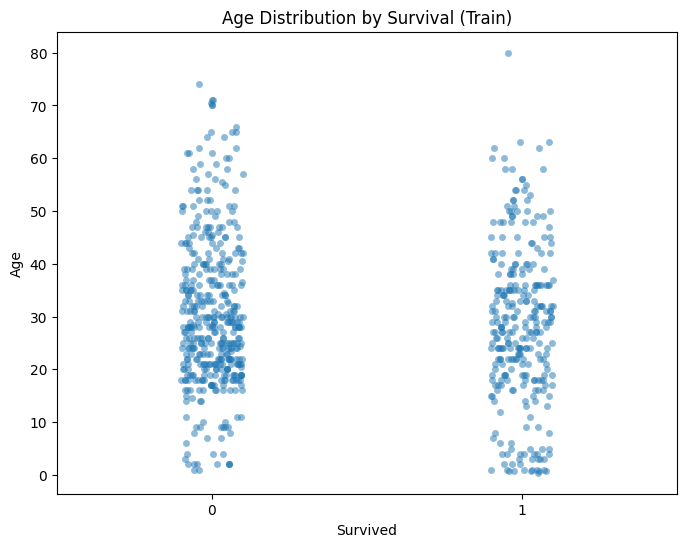

In [16]:
# Strip plot: Age distribution by Survival
plt.figure(figsize=(8,6))
sns.stripplot(x="Survived", y="Age", data=train, jitter=True, alpha=0.5)
plt.title("Age Distribution by Survival (Train)")
plt.show()

- The plot shows that passengers of all age groups either survived or did not survive.
- There is no major age difference between the two groups.

## Data Preprocessing:

In [17]:
# Fill missing Age with median
train['Age'] = train['Age'].fillna(train['Age'].median())
test['Age'] = test['Age'].fillna(test['Age'].median())

# Fill missing Fare in test set with median
test['Fare'] = test['Fare'].fillna(test['Fare'].median())

# Fill missing Embarked with mode (most common value)
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

# For Cabin: creating binary feature "HasCabin"
train['HasCabin'] = train['Cabin'].notnull().astype(int)
test['HasCabin'] = test['Cabin'].notnull().astype(int)

- I filled missing values in Age, Fare, and Embarked.
- Instead of filling Cabin, I created a new column to show whether cabin information was available.

In [18]:
# Extract Title from Name
train['Title'] = train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
test['Title'] = test['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

rare_titles = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
train['Title'] = train['Title'].replace(rare_titles, 'Rare')
test['Title'] = test['Title'].replace(rare_titles, 'Rare')

In [19]:
# Feature Engineering - family size
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

train['IsAlone'] = (train['FamilySize'] == 1).astype(int)
test['IsAlone'] = (test['FamilySize'] == 1).astype(int)

- I created a new feature called FamilySize by adding family members onboard. 
- I also created IsAlone to check if a passenger was traveling alone.

In [20]:
# Encode Sex
le_sex = LabelEncoder()
train['Sex'] = le_sex.fit_transform(train['Sex'])
test['Sex'] = le_sex.transform(test['Sex'])

# Encode Embarked
le_emb = LabelEncoder()
train['Embarked'] = le_emb.fit_transform(train['Embarked'])
test['Embarked'] = le_emb.transform(test['Embarked'])

In [21]:
# Encode Sex
le_sex = LabelEncoder()
train['Sex'] = le_sex.fit_transform(train['Sex'])
test['Sex'] = le_sex.transform(test['Sex'])

# Encode Embarked
le_emb = LabelEncoder()
train['Embarked'] = le_emb.fit_transform(train['Embarked'])
test['Embarked'] = le_emb.transform(test['Embarked'])

# Encode Title
le_title = LabelEncoder()
train['Title'] = le_title.fit_transform(train['Title'])
test['Title'] = le_title.transform(test['Title'])

In [22]:
# Select features
features = ['Pclass','Sex','Age','Fare','SibSp','Parch',
            'Embarked','HasCabin','FamilySize','IsAlone','Title']

X = train[features]
y = train['Survived']
X_test_final = test[features]

print("Preprocessed Train Shape:", X.shape)
print("Preprocessed Test Shape:", X_test_final.shape)
print("Features used:", features)

Preprocessed Train Shape: (891, 11)
Preprocessed Test Shape: (418, 11)
Features used: ['Pclass', 'Sex', 'Age', 'Fare', 'SibSp', 'Parch', 'Embarked', 'HasCabin', 'FamilySize', 'IsAlone', 'Title']


After preprocessing, 11 important features were selected for model training, and both train and test datasets are ready for modeling.

## Building predictive model

In [23]:
# Train-Test Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [24]:
# Model Evaluation Function
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Evaluation\n")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

In [25]:
# 3. LightGBM Model
lgb_model = lgb.LGBMClassifier(random_state=50)
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_val)

evaluate_model("LightGBM", y_val, lgb_preds)

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000319 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 224
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

- The LightGBM model achieved an accuracy of about 78%.
-  It performs better in predicting non-survivors than survivors, but overall the model gives balanced results.”

In [26]:
# XGBoost Model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_val)

evaluate_model("XGBoost", y_val, xgb_preds)


XGBoost Evaluation

Accuracy: 0.8212290502793296
Precision: 0.7761194029850746
Recall: 0.7536231884057971
F1 Score: 0.7647058823529411

Confusion Matrix:
 [[95 15]
 [17 52]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.86      0.86       110
           1       0.78      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



C:\Users\Bibhuprasad Das\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:43:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


- The XGBoost model achieved an accuracy of about 82%, which is higher than LightGBM.
- It shows better precision and recall, especially for predicting survivors.
- Overall, XGBoost performed better in this case.”

In [27]:
# LightGBM Hyperparameter Tuning
lgb_params = {
    'num_leaves': [31, 50],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}

lgb_grid = GridSearchCV(lgb.LGBMClassifier(random_state=42),
                        param_grid=lgb_params,
                        cv=5, scoring='accuracy', n_jobs=-1)
lgb_grid.fit(X_train, y_train)
print("\nBest LightGBM Params:", lgb_grid.best_params_)

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000290 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 224
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

After hyperparameter tuning, the best LightGBM parameters were learning rate 0.05, 100 estimators, and 31 leaves.

In [28]:
# XGBoost Hyperparameter Tuning (example)
xgb_params = {
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}

xgb_grid = GridSearchCV(xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
                        param_grid=xgb_params,
                        cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
print("Best XGBoost Params:", xgb_grid.best_params_)

Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


C:\Users\Bibhuprasad Das\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:43:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


After tuning, the best parameters for XGBoost were learning rate 0.1, max depth 3, and 200 estimators.

In [29]:
# Predict with best estimator
lgb_preds = lgb_grid.best_estimator_.predict(X_val)
evaluate_model("LightGBM (Tuned)", y_val, lgb_preds)


LightGBM (Tuned) Evaluation

Accuracy: 0.7821229050279329
Precision: 0.75
Recall: 0.6521739130434783
F1 Score: 0.6976744186046512

Confusion Matrix:
 [[95 15]
 [24 45]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.86      0.83       110
           1       0.75      0.65      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179



- After hyperparameter tuning, LightGBM did not show significant improvement.
- The accuracy remained around 78%, and the F1-score slightly decreased.

In [30]:
# 10. Hyperparameter Tuning Example
lgb_params = {
    'num_leaves': [31, 50],
    'min_child_samples': [10, 20],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [200, 500]
}

lgb_grid = GridSearchCV(lgb.LGBMClassifier(random_state=42),
                        param_grid=lgb_params,
                        cv=5, scoring='accuracy', n_jobs=-1)
lgb_grid.fit(X_train, y_train)
print("\nBest LightGBM Params:", lgb_grid.best_params_)

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000216 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 224
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

After performing a more detailed grid search, the best parameters were learning rate 0.05, 200 estimators, 31 leaves, and minimum child samples of 20.

In [31]:
xgb_params = {
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}

xgb_grid = GridSearchCV(xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
                        param_grid=xgb_params,
                        cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
print("Best XGBoost Params:", xgb_grid.best_params_)

Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


C:\Users\Bibhuprasad Das\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:44:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Comparative Analysis

In [32]:
# Evaluate tuned models
best_lgb = lgb_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

evaluate_model("LightGBM (Tuned)", y_val, best_lgb.predict(X_val))
evaluate_model("XGBoost (Tuned)", y_val, best_xgb.predict(X_val))


LightGBM (Tuned) Evaluation

Accuracy: 0.7932960893854749
Precision: 0.7424242424242424
Recall: 0.7101449275362319
F1 Score: 0.725925925925926

Confusion Matrix:
 [[93 17]
 [20 49]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83       110
           1       0.74      0.71      0.73        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179


XGBoost (Tuned) Evaluation

Accuracy: 0.7932960893854749
Precision: 0.7758620689655172
Recall: 0.6521739130434783
F1 Score: 0.7086614173228346

Confusion Matrix:
 [[97 13]
 [24 45]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.88      0.84       110
           1       0.78      0.65      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      

- After hyperparameter tuning, both LightGBM and XGBoost achieved similar accuracy of about 79%.
- However, LightGBM showed a slightly better F1-score and recall for predicting survivors.
- Therefore, LightGBM can be considered the better model for this dataset.”

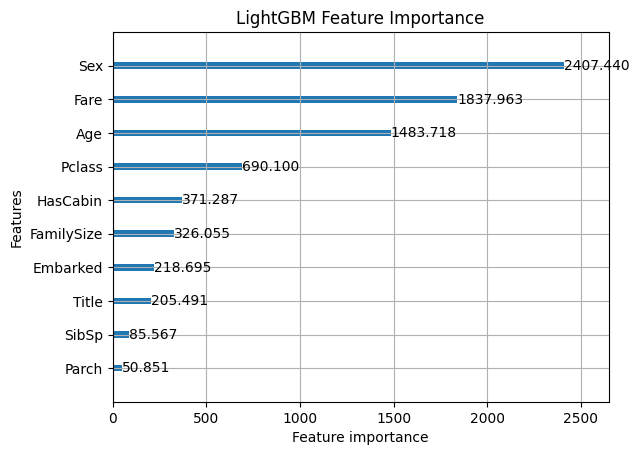

In [33]:
lgb.plot_importance(best_lgb, max_num_features=10, importance_type='gain')
plt.title("LightGBM Feature Importance")
plt.show()

- The feature importance plot shows that Sex is the most important factor affecting survival.
-  Fare, Age, and Pclass also play a significant role.
-  Family-related features have comparatively lower importance.”

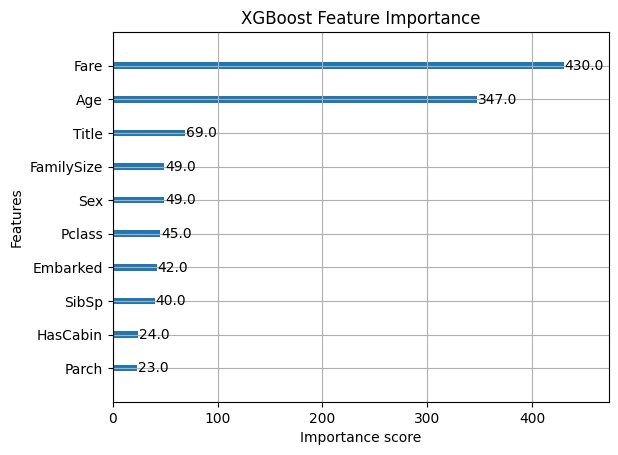

In [34]:
xgb.plot_importance(best_xgb, max_num_features=10)
plt.title("XGBoost Feature Importance")
plt.show()

- The feature importance plots show that Fare and Age are strong predictors of survival in both models.
- LightGBM considers Sex as the most important feature, while XGBoost gives highest importance to Fare.
- Overall, economic status and passenger characteristics played a major role in survival prediction.”

### Conclusion

1. This project aimed to predict passenger survival on the Titanic dataset using machine learning techniques.
2. After performing exploratory data analysis and feature engineering, LightGBM and XGBoost models were trained and optimized using GridSearchCV.
3. Both tuned models achieved an accuracy of 79.3% on the validation set.
4. However, LightGBM achieved a slightly higher F1-score (0.726) compared to XGBoost (0.709), indicating better balance between precision and recall.
5. Therefore, the tuned LightGBM model was selected as the final model for survival prediction.”